Общий объем данных (МБ): 0.23

Количество фрагментов по категориям:
category
windowwalls    301
walls          282
doors          279
Name: count, dtype: int64

Статистика размеров массивов:
Ширина (X):
count    862.000000
mean       5.085847
std        1.107281
min        3.000000
25%        4.000000
50%        5.000000
75%        6.000000
max        9.000000
Name: width, dtype: float64

Глубина (Y):
count    862.000000
mean       3.477958
std        3.126278
min        1.000000
25%        1.000000
50%        3.000000
75%        5.000000
max       25.000000
Name: depth, dtype: float64

Высота (Z):
count    862.000000
mean       3.464037
std        3.123547
min        1.000000
25%        1.000000
50%        3.000000
75%        5.000000
max       25.000000
Name: height, dtype: float64

Качество JSON:
JSON существует: 862 из 862
JSON валиден: 862 из 862

Распределение палитр:
Series([], Name: count, dtype: int64)


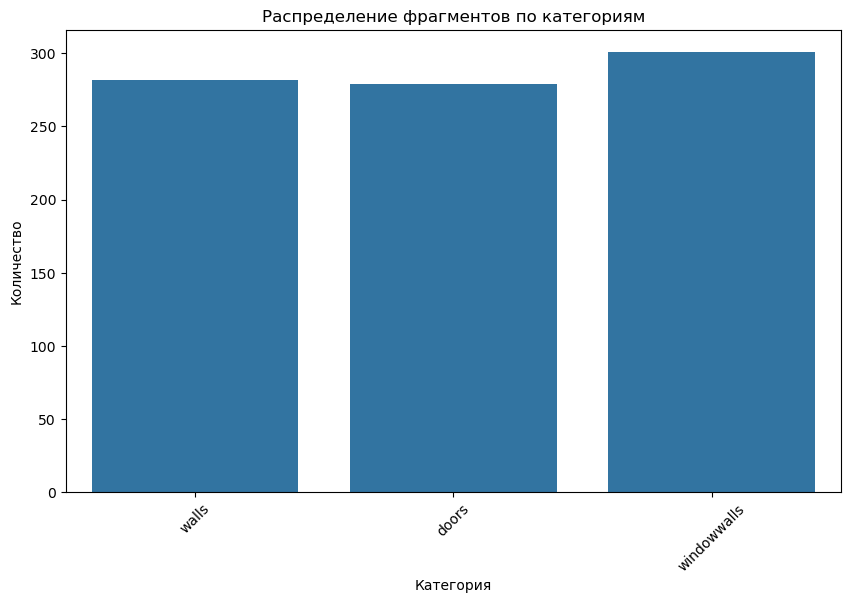

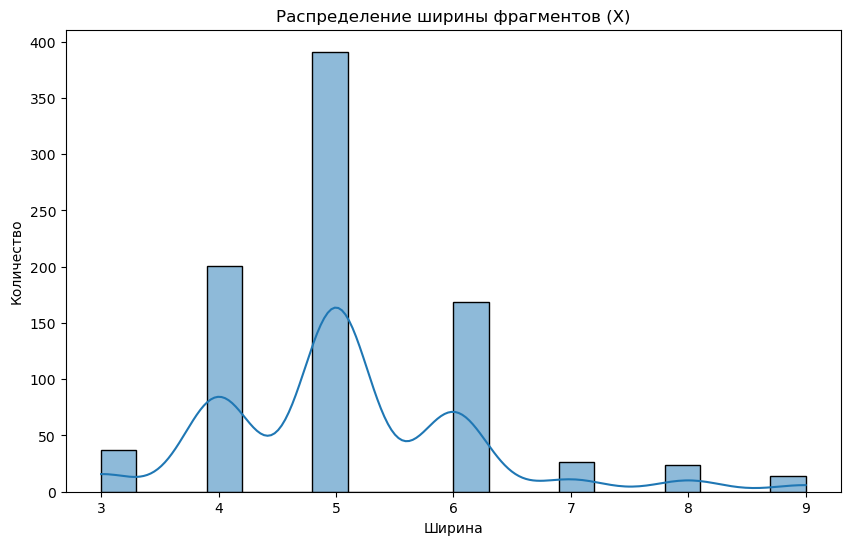

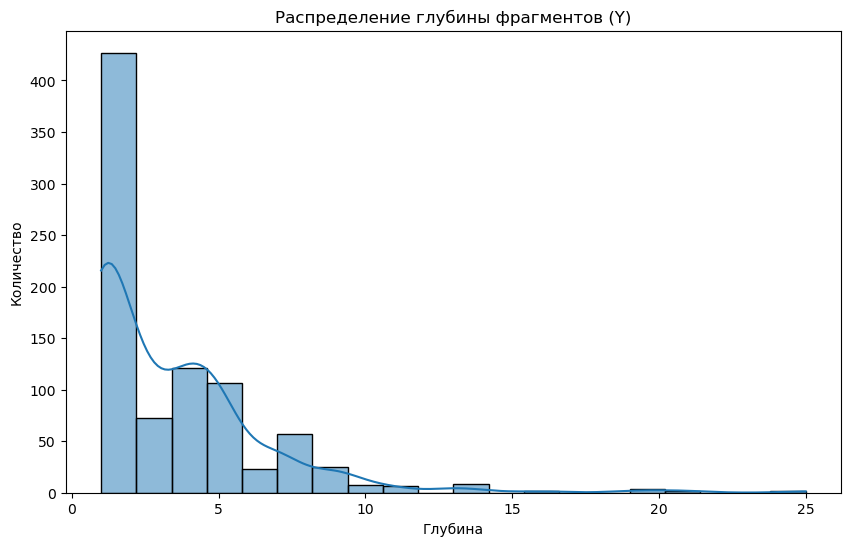

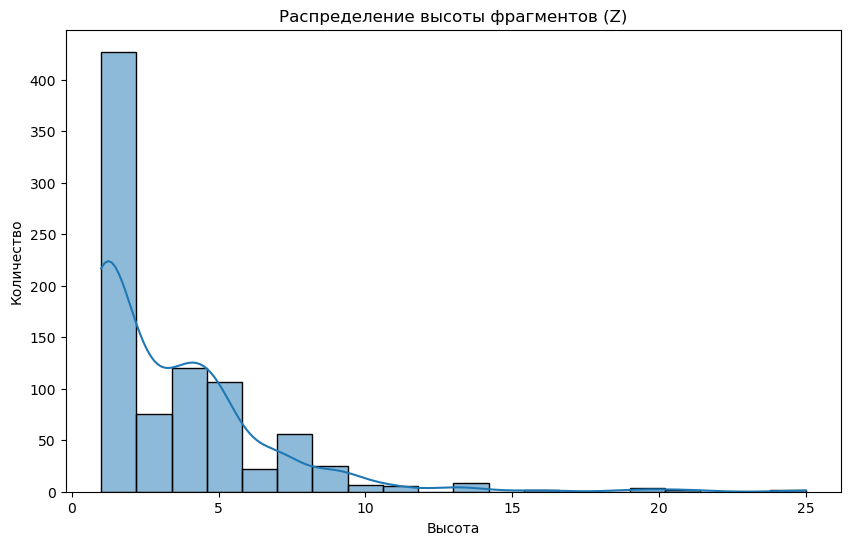


Выводы:
- Данные содержат 862 фрагментов, разделенных на 3 категорий.
- Общий объем данных: 0.23 МБ.
- Качество данных высокое: все JSON-файлы присутствуют и валидны.
- Распределение по категориям несбалансировано .
- Размеры фрагментов:
  - Средняя ширина: 5.09, медиана: 5.00
  - Средняя глубина: 3.48, медиана: 3.00
  - Средняя высота: 3.46, медиана: 3.00
- Рекомендации: добавить больше данных для категорий с малым количеством фрагментов, стандартизировать размеры массивов, дополнить JSON-файлы (например, добавить типы блоков).


In [11]:
import os
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

DATA_DIR = "data"
CATEGORIES = ["walls", "doors", "windowwalls"]

def collect_data_info():
    data_info = []
    total_size_mb = 0
    for category in CATEGORIES:
        category_path = os.path.join(DATA_DIR, category)
        if not os.path.exists(category_path):
            print(f"Категория {category} не найдена")
            continue
        for subfolder in os.listdir(category_path):
            subfolder_path = os.path.join(category_path, subfolder)
            if not os.path.isdir(subfolder_path):
                continue
            for file in os.listdir(subfolder_path):
                if file.endswith("_main.npy"):
                    npy_file = file
                    npy_path = os.path.join(subfolder_path, npy_file)
                    json_file = file.replace("_main.npy", "_palette.json")
                    json_path = os.path.join(subfolder_path, json_file)
                    
                    try:
                        array = np.load(npy_path)
                        shape = array.shape
                        size_mb = os.path.getsize(npy_path) / (1024 * 1024)
                        total_size_mb += size_mb
                    except Exception as e:
                        shape = None
                        size_mb = 0
                        print(f"Ошибка загрузки {npy_path}: {e}")
                        continue
                    
                    json_data = {}
                    json_valid = False
                    tags = []
                    palette = None
                    if os.path.exists(json_path):
                        try:
                            with open(json_path, "r") as f:
                                json_data = json.load(f)
                            json_valid = True
                            tags = json_data.get("tags", [])
                            palette = json_data.get("palette", None)
                        except Exception as e:
                            print(f"Ошибка загрузки {json_path}: {e}")
                    
                    data_info.append({
                        "category": category,
                        "subfolder": subfolder,
                        "npy_file": npy_file,
                        "json_file": json_file,
                        "shape": shape,
                        "size_mb": size_mb,
                        "json_exists": os.path.exists(json_path),
                        "json_valid": json_valid,
                        "tags": tags,
                        "palette": palette
                    })
    return data_info, total_size_mb

data_info, total_size_mb = collect_data_info()
if not data_info:
    print("Данные не найдены. Проверьте структуру папок и наличие файлов.")
else:
    df = pd.DataFrame(data_info)

    print("Общий объем данных (МБ):", round(total_size_mb, 2))
    print("\nКоличество фрагментов по категориям:")
    print(df["category"].value_counts())
    print("\nСтатистика размеров массивов:")
    df["width"] = df["shape"].apply(lambda x: x[0] if x else None)
    df["depth"] = df["shape"].apply(lambda x: x[1] if x else None)
    df["height"] = df["shape"].apply(lambda x: x[2] if len(x) == 3 else 1)
    print("Ширина (X):")
    print(df["width"].describe())
    print("\nГлубина (Y):")
    print(df["depth"].describe())
    print("\nВысота (Z):")
    print(df["height"].describe())
    print("\nКачество JSON:")
    print("JSON существует:", df["json_exists"].sum(), "из", len(df))
    print("JSON валиден:", df["json_valid"].sum(), "из", len(df))

    print("\nРаспределение палитр:")
    palette_counts = df["palette"].value_counts()
    print(palette_counts)

    missing_json = df[~df["json_exists"]]
    if not missing_json.empty:
        print("\nФайлы без JSON:")
        print(missing_json[["category", "subfolder", "npy_file"]])

    invalid_json = df[df["json_exists"] & ~df["json_valid"]]
    if not invalid_json.empty:
        print("\nФайлы с невалидным JSON:")
        print(invalid_json[["category", "subfolder", "npy_file"]])

    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x="category")
    plt.title("Распределение фрагментов по категориям")
    plt.xlabel("Категория")
    plt.ylabel("Количество")
    plt.xticks(rotation=45)
    plt.savefig("category_distribution.png")
    plt.show()

    if not palette_counts.empty:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x="palette")
        plt.title("Распределение палитр")
        plt.xlabel("Палитра")
        plt.ylabel("Количество")
        plt.xticks(rotation=45)
        plt.savefig("palette_distribution.png")
        plt.show()

    plt.figure(figsize=(10, 6))
    sns.histplot(df["width"].dropna(), bins=20, kde=True)
    plt.title("Распределение ширины фрагментов (X)")
    plt.xlabel("Ширина")
    plt.ylabel("Количество")
    plt.savefig("width_distribution.png")
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.histplot(df["depth"].dropna(), bins=20, kde=True)
    plt.title("Распределение глубины фрагментов (Y)")
    plt.xlabel("Глубина")
    plt.ylabel("Количество")
    plt.savefig("depth_distribution.png")
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.histplot(df["height"].dropna(), bins=20, kde=True)
    plt.title("Распределение высоты фрагментов (Z)")
    plt.xlabel("Высота")
    plt.ylabel("Количество")
    plt.savefig("height_distribution.png")
    plt.show()

    print("\nВыводы:")
    print("- Данные содержат", len(df), "фрагментов, разделенных на", len(CATEGORIES), "категорий.")
    print("- Общий объем данных:", round(total_size_mb, 2), "МБ.")
    if not missing_json.empty or not invalid_json.empty:
        print("- Проблемы с качеством: есть файлы без JSON или с невалидным JSON. Рекомендуется проверить файлы и исправить ошибки.")
    else:
        print("- Качество данных высокое: все JSON-файлы присутствуют и валидны.")
    print("- Распределение по категориям", "сбалансировано" if df["category"].value_counts().std() < 10 else "несбалансировано", ".")
    if not palette_counts.empty:
        print("- Популярные палитры:", ", ".join(palette_counts.index[:3]))
    print("- Размеры фрагментов:")
    print(f"  - Средняя ширина: {df['width'].mean():.2f}, медиана: {df['width'].median():.2f}")
    print(f"  - Средняя глубина: {df['depth'].mean():.2f}, медиана: {df['depth'].median():.2f}")
    print(f"  - Средняя высота: {df['height'].mean():.2f}, медиана: {df['height'].median():.2f}")
    print("- Рекомендации: добавить больше данных для категорий с малым количеством фрагментов, стандартизировать размеры массивов, дополнить JSON-файлы (например, добавить типы блоков).")